In [1]:
from transformers import TimesformerForVideoClassification

In [2]:
from transformers import AutoImageProcessor, TimesformerModel

In [3]:
import torch
import numpy as np
import av
from pathlib import Path 
import matplotlib.pyplot as plt

In [4]:
vod_title = "M8 vs. EDG - VALORANT Masters Santiago - SWISS"
video_path = Path(f"../../data/vods/{vod_title}.mp4")

In [5]:
def read_video_pyav(container,indices):
    '''
    Decode the video with PyAV decoder.
    Args:
        container (`av.container.input.InputContainer`): PyAV container.
        indices (`list[int]`): List of frame indices to decode.
    Returns:
        result (np.ndarray): np array of decoded frames of shape (num_frames, height, width, 3).
    '''
    frames = []
    container.seek(0)
    start_index = indices[0]
    end_index = indices[-1]
    for i,frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        if i >=start_index and i in indices:
            frames.append(frame)
    return np.stack([x.to_ndarray(format="rgb24") for x in frames])

def sample_frame_indices(clip_len, frame_sample_rate, seg_len):
    '''
    Sample a given number of frame indices from the video.
    Args:
        clip_len (`int`): Total number of frames to sample.
        frame_sample_rate (`int`): Sample every n-th frame.
        seg_len (`int`): Maximum allowed index of sample's last frame.
    Returns:
        indices (`list[int]`): List of sampled frame indices
    '''
    converted_len = int(clip_len * frame_sample_rate)
    end_idx = np.random.randint(converted_len, seg_len)
    start_idx = end_idx - converted_len
    indices = np.linspace(start_idx, end_idx, num=clip_len)
    indices = np.clip(indices, start_idx, end_idx - 1).astype(np.int64)
    return indices
def sample_indices_from_start(start_sec,fps,num_frames=8,sample_fps=4,offset_sec=0.0):
    """
    start_secから一定間隔でフレームindexを取る。

    Args:
        start_sec: ラウンド開始秒
        fps: 動画fps
        num_frames: 取るフレーム数
        sample_fps: 1秒あたり何枚取るか
        offset_sec: start_secから何秒後を起点にするか

    Returns:
        indices: フレームindexのnp.ndarray
    """
    start_frame = int((start_sec+offset_sec)*fps)
    step = max(1,int(round(fps/sample_fps)))
    indices = start_frame + np.arange(num_frames) * step
    return indices.astype(np.int64)
   

## TODO / 注意: read_video_pyav の改善余地

現在の `read_video_pyav` は、`container.seek(0)` で毎回動画の先頭付近に戻してから decode している。

少数のclip確認では問題ないが、各ラウンド・各時刻のclipを大量に読む学習時には遅くなる可能性がある。

今はまず以下を優先する：
1. start_sec からフレームを取れるか確認
2. minimap crop が正しいか確認
3. TimeSformer に入る shape に変換できるか確認

高速化は後で検討する：
- OpenCV の `cap.set(CAP_PROP_POS_FRAMES, frame_idx)` を使う
- PyAV の seek を対象時刻付近にする
- 事前にclipを保存しておく
- Dataset/DataLoaderで読み込みを最適化する

In [6]:
container = av.open(video_path)
stream = container.streams.video[0]
fps = float(stream.average_rate)

indices = sample_indices_from_start(start_sec=10,fps=fps,num_frames=8,sample_fps=4,offset_sec=15.0)
video = read_video_pyav(container,indices)

image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
model = TimesformerForVideoClassification.from_pretrained(
    "facebook/timesformer-base-finetuned-k400",
    num_labels=2,
    ignore_mismatched_sizes=True,
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `400`.


Loading weights:   0%|          | 0/249 [00:00<?, ?it/s]

[transformers] TimesformerForVideoClassification LOAD REPORT from: facebook/timesformer-base-finetuned-k400
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([400, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([400]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [41]:
def crop_map_from_video(video):
    x1,x2 = 65,445
    y1,y2 = 50,430
    return video[:,y1:y2,x1:x2,:]

haven以外でも同じ範囲でよいか確かめる

In [8]:
print(video.shape)
print(model.config.num_frames)
print(model.config.image_size)

(8, 1080, 1920, 3)
8
224


In [44]:
minimap = crop_map_from_video(video)
print(minimap.shape)

(8, 380, 380, 3)


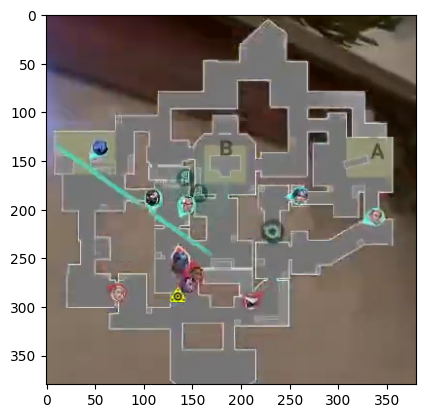

In [45]:
import matplotlib.pyplot as plt
plt.imshow(minimap[-1])
plt.show()

In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [50]:
model.to(device)
model.train()

inputs = image_processor(list(minimap),
                         return_tensors="pt",
                         )

pixel_values = inputs["pixel_values"].to(device)

labels = torch.tensor([1],device=device)
outputs = model(
    pixel_values=pixel_values,
    labels = labels,
)

loss = outputs.loss
logits = outputs.logits

print("pixel_values shape :",pixel_values.shape)
print("loss :",loss.item())
print("logis shpae :",logits.shape)
print("logits :",logits)


pixel_values shape : torch.Size([1, 8, 3, 224, 224])
loss : 1.7570288181304932
logis shpae : torch.Size([1, 2])
logits : tensor([[ 1.0948, -0.4728]], grad_fn=<AddmmBackward0>)


In [54]:
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-5)

print("loss before backward :",loss.item() )

loss.backward()
optimizer.step()
optimizer.zero_grad()

print("done")

loss before backward : 1.7570288181304932
done


In [55]:
outputs = model(
    pixel_values=pixel_values,
    labels = labels,
)

loss = outputs.loss
logits = outputs.logits

print("pixel_values shape :",pixel_values.shape)
print("loss :",loss.item())
print("logis shpae :",logits.shape)
print("logits :",logits)

pixel_values shape : torch.Size([1, 8, 3, 224, 224])
loss : 0.5600969791412354
logis shpae : torch.Size([1, 2])
logits : tensor([[0.3030, 0.5896]], grad_fn=<AddmmBackward0>)
